# Issue 08 — Named Aesthetics Per Decade: Primary Count via Aesthetics Wiki

**Purpose:** original tally of how many distinct, fashion/style-relevant named aesthetics the Aesthetics Wiki (aesthetics.fandom.com) categorizes per decade, as a primary data point for the "categorization accelerating" mechanism. This is original data compilation, not a
cited third-party stat, no one has published this specific count before.

**Method:** Fandom wikis run on MediaWiki, which exposes a public `api.php` endpoint. We use `list=categorymembers` to pull the members of each decade category (`Category:1990s`, `Category:2000s`, `Category:2010s`, `Category:2020s`), then intersect those with `Category:Fashion_Styles` (and optionally `Category:Internet_Aesthetics`) to scope the count to fashion/style-relevant entries only, excluding music-genre-only and fiction-only aesthetics.

**Known limitation, disclose in sources.md regardless of what the count shows:** The wiki was
founded in 2018. A rising count by decade may partly reflect more active documentation of
recent trends rather than a real acceleration in how many aesthetics get named. This doesn't
necessarily invalidate the count, but it means the count alone can't fully separate
"more aesthetics exist now" from "more get written up now." Worth pairing with the DataReportal
exposure figure and framing carefully rather than presenting the raw count as a clean causal
signal.

## 1. Setup

In [1]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import json
import time
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

RAW_DIR = Path("../../../data/raw/cycle 2/issue-08")
PROCESSED_DIR = Path("../../../data/processed/cycle 2/issue-08")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

API_URL = "https://aesthetics.fandom.com/api.php"
HEADERS = {"User-Agent": "data-worn-thin-research/1.0 (personal research project)"}

## 2. Load brand palette

In [2]:
# load brand palette
with open("../../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

## 3. Extracting / analyzing data

### 3.1 Pull category members via the MediaWiki API

`cmlimit=500` should cover each category in one request (verify against the "All items (N)"
count shown on each category page: Fashion Styles = 117 at time of writing; decade categories
not yet checked). If a category exceeds 500 members, this needs pagination via the `cmcontinue`
token in the response, not currently implemented, check the raw response for a `continue` key
before trusting a category's count as complete.

In [3]:
def get_category_members(category, limit=500):
    """Pull all page titles in a Fandom category via the MediaWiki API."""
    params = {
        "action": "query",
        "list": "categorymembers",
        "cmtitle": f"Category:{category}",
        "cmlimit": limit,
        "format": "json",
    }
    resp = requests.get(API_URL, params=params, headers=HEADERS)
    try:
        data = resp.json()
    except Exception:
        print(f"Non-JSON response for {category}: {resp.text[:500]}")
        raise

    if "error" in data:
        # Mirror the FRED lesson: surface the actual error object before debugging further.
        print(f"API error for {category}: {data['error']}")
        raise RuntimeError(data["error"])

    members = [m["title"] for m in data.get("query", {}).get("categorymembers", [])]

    if "continue" in data:
        print(f"WARNING: {category} has more than {limit} members — pagination not yet "
              f"implemented, this count is INCOMPLETE.")

    return members

DECADES = ["1990s", "2000s", "2010s", "2020s"]
decade_members = {}
for decade in DECADES:
    decade_members[decade] = get_category_members(decade)
    print(f"{decade}: {len(decade_members[decade])} members")
    time.sleep(1)  # be polite to the API

fashion_members = set(get_category_members("Fashion_Styles"))
print(f"Fashion Styles: {len(fashion_members)} members")

1990s: 160 members
2000s: 183 members
2010s: 224 members
2020s: 230 members
Fashion Styles: 93 members


### 3.2 Scope to fashion/style-relevant entries

Intersect each decade's members with the `Fashion_Styles` category. Anything in a decade
category but NOT in `Fashion_Styles` (a music genre, a design movement, a fictional aesthetic)
is excluded, per the "fashion-relevant only" scoping rule.

In [4]:
fashion_by_decade = {
    decade: sorted(set(members) & fashion_members)
    for decade, members in decade_members.items()
}

counts = {decade: len(names) for decade, names in fashion_by_decade.items()}
print(counts)

df = pd.DataFrame(
    [(decade, name) for decade, names in fashion_by_decade.items() for name in names],
    columns=["decade", "aesthetic_name"],
)
df.head()

{'1990s': 9, '2000s': 13, '2010s': 13, '2020s': 30}


,decade,aesthetic_name
0,1990s,Berlin Techno Fashion
1,1990s,Bodikon
2,1990s,Cyberpop
3,1990s,Girly Kei
4,1990s,Heroin Chic


In [ ]:
# save the raw pull
raw_path = RAW_DIR / "fashion_aesthetics_by_decade.csv"
df.to_csv(raw_path, index=False)
print(f"Saved raw pull to {raw_path}")

## 4. Plot

Only exploratory analysis is conducted at this stage. This schecks whether the count actually shows a meaningful climb by decade before deciding whether this is strong enough to use, and whether the 1990s baseline is near-zero (expected, given internet aesthetic culture didn't really start until the 2000s–2010s).

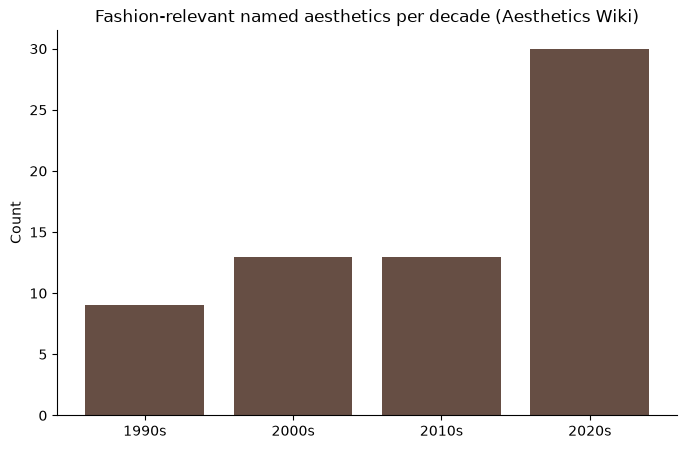

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
decades_sorted = sorted(counts.keys())
values = [counts[d] for d in decades_sorted]
ax.bar(decades_sorted, values, color=COCOA)
ax.set_title("Fashion-relevant named aesthetics per decade (Aesthetics Wiki)")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

## 5. Findings

- **Does the count actually climb decade over decade, or is it flatter/noisier than expected?**  
  Neither smoothly climbing nor flat: 1990s: 9, 2000s: 13, 2010s: 13, 2020s: 30. The first three decades move gently and plateau (2000s and 2010s are identical), then the 2020s more than doubles. This is not a steady acceleration, it's three flat-ish decades followed by one large jump.
- **Did any category exceed the 500-member limit?**  
  No. Largest decade category (2020s) was 230 raw members, comfortably under the cap, no pagination warning fired.
- **Manual spot-check of `Fashion_Styles` scoping:**  
  Unresolved. The API's `categorymembers` pull returned 93 members, but the wiki's own category page displays "All items (117)." That's a ~20% gap, not yet explained (possible causes: `cmtype` defaulting to exclude
  subcategories/files, or the category changing between when it was checked manually and when the pull ran). Not confirmed which, and not corrected for in this count.
- **How much of the 2020s figure is documentation bias vs. real acceleration?**  
  Can't be separated with this data alone. The wiki was founded in 2018, so heavier documentation of recent trends is a live, plausible explanation for the 2020s jump specifically, and the flat 2000s/2010s plateau is consistent with that story (older decades getting a baseline level of retroactive coverage that doesn't grow). A page-creation-timestamp check (are 1990s-tagged pages themselves old, or were they also writte recently?) would help settle this, but wasn't run.
- **Editorial decision:**  
  Given the ambiguity above (both the unresolved count discrepancy and the inability to separate real acceleration from documentation bias), this data point
  is used in the issue as a disclosed, heavily caveated secondary point, not as the hook stat. The `08.1` trendspy build-time/burn-time finding is the stronger, cleaner data point and carries the mechanism instead.